# Mass envelopes phenomenology

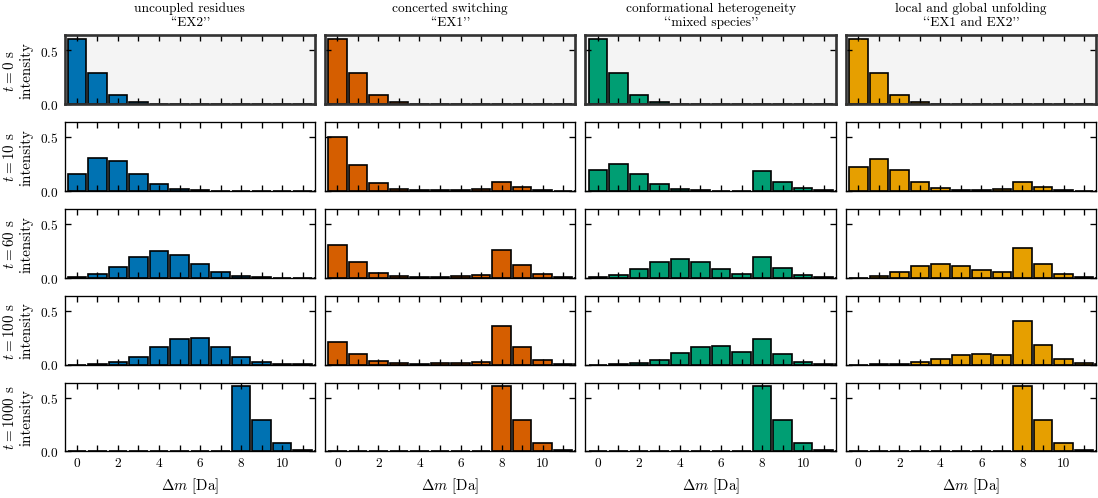

In [2]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt

_here = os.getcwd()
_py = os.path.abspath(os.path.join(_here, '..', 'python'))
if _py not in sys.path:
    sys.path.insert(0, _py)

import hdx_env as H
from hdx_env import (UncoupledResidues, ConcertedSwitching,
                     MetastableBasins, averagine_composition,
                     natural_envelope, mass_envelope, COLORS)
H.set_plot_style(use_tex=False)

PLOTS_DIR = os.path.abspath(os.path.join(_here, '..', 'figures'))
os.makedirs(PLOTS_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Common peptide parameters (match fig_uptake_phenomenology_v2.ipynb).
# k_int = 1 throughout# ---------------------------------------------------------------------------
N       = 8
P       = tuple(range(N))
k_int   = np.ones(N)
t_snaps = np.array([0.0, 10.0, 60.0, 100.0, 1000.0])

kop, kcl = 0.01, 0.1

ud_a = UncoupledResidues(np.full(N, kop), np.full(N, kcl),
                           k_int).uptake_distribution(P, t_snaps)
ud_b = ConcertedSwitching(kop, kcl,
                          k_int).uptake_distribution(P, t_snaps)

pi_basins_c = np.stack([
    np.full(N, 0.01),
    np.full(N, 1),
])
p0_basins_c = np.array([0.70, 0.30])
ud_c = MetastableBasins(pi_basins_c, k_int,
                        p0_basin=p0_basins_c).uptake_distribution(P, t_snaps)

W_d = np.array((
    [-kop, +kop],
    [+kcl, -kcl]
))
ud_d = MetastableBasins(pi_basins_c, k_int,
                        W_basin=W_d).uptake_distribution(P, t_snaps)

scenarios = [
    ('a', "uncoupled residues\n``EX2''",                        ud_a, COLORS['uncoupled']),
    ('b', "concerted switching\n``EX1''",                       ud_b, COLORS['concerted']),
    ('c', "conformational heterogeneity\n``mixed species''",    ud_c, COLORS['basins']),
    ('d', "local and global unfolding\n``EX1 and EX2''",        ud_d, COLORS['other1']),
    #('e', 'mixed (4 EX1 + 4 EX2)',        ud_e, COLORS.get('other2', '#8c6bb1')),
]

peptide_mass = 110.0 * N
nat_env      = natural_envelope(averagine_composition(peptide_mass), n_peaks=15)
L_env        = N + len(nat_env)

fig, axes = plt.subplots(len(t_snaps), len(scenarios),
                         figsize=(9.2, 4.2),
                         sharex=True, sharey=True,
                         constrained_layout=True)
offs = np.arange(L_env)

x_ticks = np.arange(0,N+4,1)
x_ticklabels = [tick if tick % 2 == 0 else '' for tick in x_ticks]

for ri, (label, title, ud, col) in enumerate(scenarios):
    for ti, tsnap in enumerate(t_snaps):
        ax  = axes[ti, ri]
        env = mass_envelope(ud[ti:ti+1], nat_env, n_peaks=L_env)[0]
        ax.bar(offs[:len(env)], env, width=0.9,
               color=col, edgecolor='black', lw=1)
        if ti == 0:
            ax.set_title(title, fontsize=8)
            ax.text(0.03, 0.94, label, transform=ax.transAxes,
                    fontsize=9, fontweight='bold', color=col,
                    va='top', ha='left')
            for sp in ax.spines.values():
                sp.set_linewidth(1.6)
                sp.set_color('0.2')
            ax.set_facecolor('#f4f4f4')
        if ri == 0:
            ax.set_ylabel(rf'$t={tsnap:g}$ s' + '\n' + r'intensity')
        if ti == len(t_snaps) - 1:
            ax.set_xlabel(r'$\Delta m$ [Da]')
        ax.set_xlim(-0.6, N + 3.6)
        ax.set_xticks(x_ticks, labels=x_ticklabels)


fig.savefig(os.path.join(PLOTS_DIR, 'fig_mass_envelope_phenomenology.pdf'))
plt.show()